In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

import time
import psutil


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)



In [3]:


#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
    ])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)



In [4]:
# 5. MLP Starter Code
class InitialMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x


In [5]:

# 6. Initialize Network
model = InitialMLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [6]:

# 7. Training Function
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.tolist())
        all_labels.extend(labels.tolist())

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1, gradient_norms


In [7]:

# 8. Testing Function
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.tolist())
            all_labels.extend(labels.tolist())

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    test_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, accuracy, test_f1


In [8]:
num_epochs = 15

train_losses = []
test_losses = []

train_accs = []
test_accs = []

train_f1s = []
test_f1s = []
all_epoch_gradient_norms = []

process = psutil.Process()
train_start_time = time.time()

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats(device)

for epoch in range(num_epochs):

    # 1. Run training and testing
    train_loss, train_acc, train_f1, grad_norms = train(model, train_loader)
    test_loss, test_acc, test_f1 = test(model, test_loader)

    # 2. Storage
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
    # 3. Process Gradients (Fixed variable name here)
    epoch_grad_averages = {}
    for layer_name, batch_norms in grad_norms.items():
        epoch_grad_averages[layer_name] = sum(batch_norms) / len(batch_norms)
    
    all_epoch_gradient_norms.append(epoch_grad_averages)
    
    # 4. MONITORING
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}% | Test Accuracy: {test_acc:.2f}%")
    print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f}")

    # --- ADDED: Print Gradient Magnitudes ---
    print("Average Gradient Magnitudes:")
    for layer, magnitude in epoch_grad_averages.items():
        # Using :.6f because these numbers might be very small!
        print(f"  {layer}: {magnitude:.6f}")

    print("-" * 40)

train_end_time = time.time()
training_time_seconds = train_end_time - train_start_time

cpu_memory_rss_bytes = process.memory_info().rss
cpu_memory_mb = cpu_memory_rss_bytes / 1024 ** 2

gpu_memory_mb = None
if torch.cuda.is_available():
    gpu_memory_bytes = torch.cuda.max_memory_allocated(device)
    gpu_memory_mb = gpu_memory_bytes / 1024 ** 2


Epoch 1/15
Train Loss: 1.6293 | Test Loss: 1.4896
Train Accuracy: 42.10% | Test Accuracy: 46.70%
Train F1: 0.4165 | Test F1: 0.4555
Average Gradient Magnitudes:
  fc1.weight: 0.403128
  fc1.bias: 0.015191
  fc2.weight: 0.907804
  fc2.bias: 0.025454
  fc3.weight: 1.493773
  fc3.bias: 0.086698
----------------------------------------
Epoch 2/15
Train Loss: 1.4112 | Test Loss: 1.4048
Train Accuracy: 50.21% | Test Accuracy: 49.99%
Train F1: 0.4981 | Test F1: 0.4932
Average Gradient Magnitudes:
  fc1.weight: 0.410486
  fc1.bias: 0.015700
  fc2.weight: 0.963627
  fc2.bias: 0.020907
  fc3.weight: 1.760873
  fc3.bias: 0.082713
----------------------------------------
Epoch 3/15
Train Loss: 1.2980 | Test Loss: 1.3617
Train Accuracy: 54.27% | Test Accuracy: 52.44%
Train F1: 0.5396 | Test F1: 0.5219
Average Gradient Magnitudes:
  fc1.weight: 0.424825
  fc1.bias: 0.016043
  fc2.weight: 1.012865
  fc2.bias: 0.019559
  fc3.weight: 1.871831
  fc3.bias: 0.078671
---------------------------------------

In [9]:
# Compare between CNN to MLP

import matplotlib.pyplot as plt

epochs = range(1, 16)

# CNN Data (Improved Version)
cnn_train_acc = [30.77, 51.49, 61.16, 67.21, 70.87, 74.26, 76.74, 79.22, 80.92, 83.39, 85.54, 87.86, 89.23, 91.01, 92.88]
cnn_test_acc = [45.81, 57.05, 63.61, 66.81, 69.59, 71.84, 72.30, 74.58, 74.91, 74.03, 75.94, 75.56, 75.56, 74.76, 75.69]

cnn_train_loss = [1.8353, 1.3177, 1.0730, 0.9199, 0.8221, 0.7337, 0.6622, 0.5938, 0.5426, 0.4760, 0.4159, 0.3509, 0.3091, 0.2573, 0.2100]
cnn_test_loss = [1.4571, 1.1647, 1.0244, 0.9469, 0.8655, 0.8087, 0.7858, 0.7278, 0.7423, 0.7651, 0.7344, 0.7744, 0.7818, 0.8617, 0.8406]

cnn_train_f1 = [
    0.2963, 0.5102, 0.6073, 0.6692, 0.7095,
    0.7472, 0.7724, 0.7963, 0.8153, 0.8380,
    0.8597, 0.8824, 0.9004, 0.9175, 0.9350
]
cnn_test_f1 = [
    0.4397, 0.5764, 0.6314, 0.6672, 0.6942,
    0.7221, 0.7219, 0.7524, 0.7408, 0.7397,
    0.7562, 0.7606, 0.7566, 0.7559, 0.7580
]

# MLP Data
mlp_train_acc = [42.22, 50.16, 54.22, 57.70, 60.73, 63.73, 66.51, 69.16, 71.73, 74.13, 76.92, 78.79, 81.33, 82.68, 84.72]
mlp_test_acc = [46.83, 50.54, 52.75, 51.74, 52.54, 54.10, 53.96, 53.43, 53.61, 54.33, 53.24, 53.44, 53.45, 53.67, 53.69]

mlp_train_loss = [1.6279, 1.4086, 1.2965, 1.2011, 1.1137, 1.0310, 0.9478, 0.8720, 0.7966, 0.7270, 0.6508, 0.5960, 0.5335, 0.4872, 0.4341]
mlp_test_loss = [1.4804, 1.3967, 1.3646, 1.4090, 1.3491, 1.3537, 1.3957, 1.4232, 1.5003, 1.5429, 1.6246, 1.7293, 1.8316, 1.8890, 2.0337]

mlp_train_f1 = [
    0.4165, 0.4981, 0.5396, 0.5740, 0.6050,
    0.6343, 0.6620, 0.6898, 0.7150, 0.7390,
    0.7653, 0.7891, 0.8098, 0.8300, 0.8475
]
mlp_test_f1 = [
    0.4555, 0.4932, 0.5219, 0.5240, 0.5285,
    0.5368, 0.5430, 0.5422, 0.5349, 0.5403,
    0.5431, 0.5426, 0.5436, 0.5377, 0.5362
]


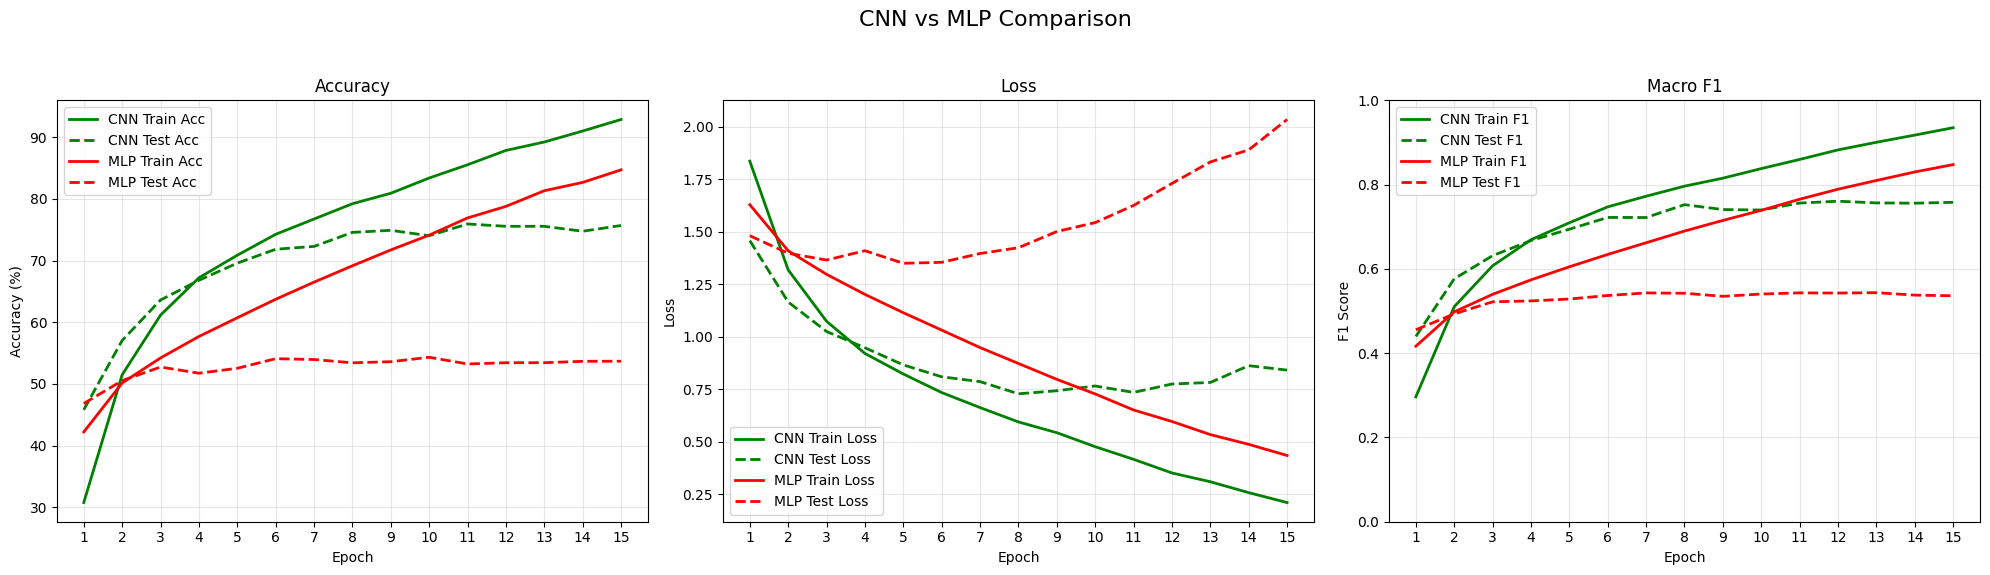

In [10]:
epochs = range(1, 16)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('CNN vs MLP Comparison', fontsize=16)

# --- Plot 1: Accuracy ---
ax1.plot(epochs, cnn_train_acc, 'g-', label='CNN Train Acc', linewidth=2)
ax1.plot(epochs, cnn_test_acc, 'g--', label='CNN Test Acc', linewidth=2)
ax1.plot(epochs, mlp_train_acc, 'r-', label='MLP Train Acc', linewidth=2)
ax1.plot(epochs, mlp_test_acc, 'r--', label='MLP Test Acc', linewidth=2)
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(epochs)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Loss ---
ax2.plot(epochs, cnn_train_loss, 'g-', label='CNN Train Loss', linewidth=2)
ax2.plot(epochs, cnn_test_loss, 'g--', label='CNN Test Loss', linewidth=2)
ax2.plot(epochs, mlp_train_loss, 'r-', label='MLP Train Loss', linewidth=2)
ax2.plot(epochs, mlp_test_loss, 'r--', label='MLP Test Loss', linewidth=2)
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_xticks(epochs)
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: F1 Score ---
ax3.plot(epochs, cnn_train_f1, 'g-', label='CNN Train F1', linewidth=2)
ax3.plot(epochs, cnn_test_f1, 'g--', label='CNN Test F1', linewidth=2)
ax3.plot(epochs, mlp_train_f1, 'r-', label='MLP Train F1', linewidth=2)
ax3.plot(epochs, mlp_test_f1, 'r--', label='MLP Test F1', linewidth=2)
ax3.set_title('Macro F1')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1 Score')
ax3.set_xticks(epochs)
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [11]:
# 1. Define the MLP model variable
mlp_model = InitialMLP().to(device)

# 2. Add the counting function
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 3. Print the count
print(f"MLP Parameters: {count_parameters(mlp_model)}")

MLP Parameters: 1707274


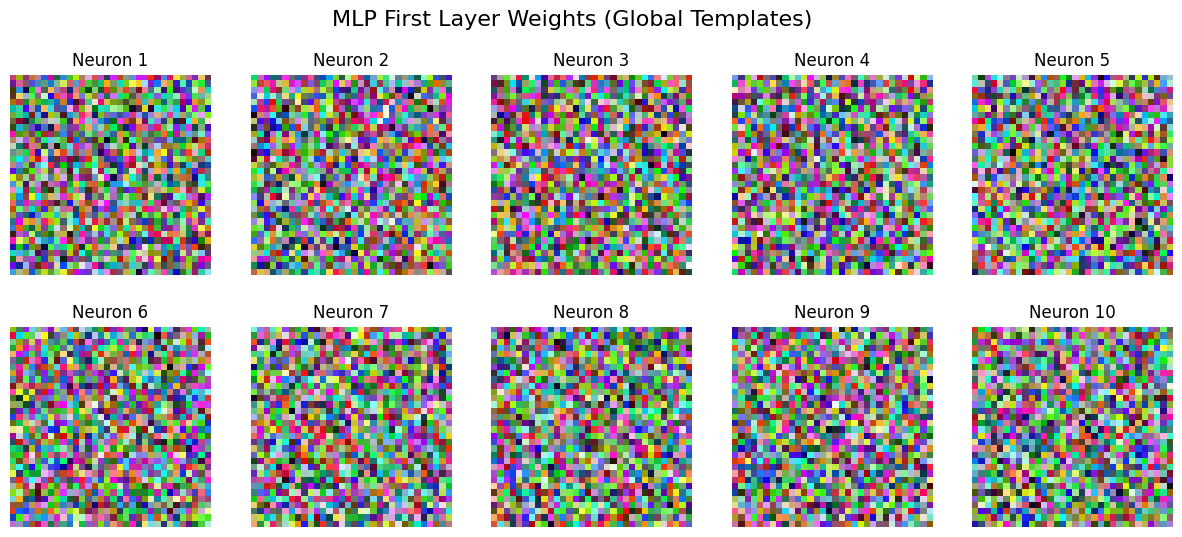

In [12]:
# Access the weights of the first linear layer

# Shape is [hidden_neurons, input_features] -> [512, 3072]

weights = mlp_model.fc1.weight.detach().cpu()



# Plot the first 10 neurons' weight "templates"

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

fig.suptitle("MLP First Layer Weights (Global Templates)", fontsize=16)



for i, ax in enumerate(axes.flat):

# Reshape the 3072 weights back to (3, 32, 32) and then permute to (32, 32, 3)

    template = weights[i].view(3, 32, 32).permute(1, 2, 0)


# Normalize to [0, 1]

    t_min, t_max = template.min(), template.max()

    template = (template - t_min) / (t_max - t_min)


    ax.imshow(template.numpy())

    ax.set_title(f"Neuron {i+1}")

    ax.axis('off')

plt.show()

In [13]:
# Summary: model size, training time, and memory use

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp_parameter_count = count_trainable_parameters(model)
mlp_parameter_count_str = f"{mlp_parameter_count:,}"

print(f"MLP trainable parameters: {mlp_parameter_count_str}")
print(f"Training time: {training_time_seconds:.2f} seconds")
print(f"CPU memory usage after training: {cpu_memory_mb:.2f} MB")

if gpu_memory_mb is not None:
    print(f"Peak GPU memory allocated during training: {gpu_memory_mb:.2f} MB")
else:
    print("CUDA not available, GPU memory not measured.")


MLP trainable parameters: 1,707,274
Training time: 656.63 seconds
CPU memory usage after training: 674.35 MB
CUDA not available, GPU memory not measured.
